### INTERACTION BOUTS: GROUP-HOUSED V SOCIALLY ISOLATED


In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
try:
    from IPython.display import display
except ImportError:
    display = print

# Adobe-friendly fonts, set before plotting.
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [89]:
# Load bout tables and label each condition.
df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/interaction_type_bout.csv')
df1['Social experience'] = 's'
df1['Food condition'] = 'Fed-Fed'
df1['Condition'] = 's Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/interaction_type_bout.csv')
df2['Social experience'] = 's'
df2['Food condition'] = 'Fed-Starved'
df2['Condition'] = 's Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/interaction_type_bout.csv')
df3['Social experience'] = 's'
df3['Food condition'] = 'Starved-Starved'
df3['Condition'] = 's Starved-Starved'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interaction_type_bout.csv')
df4['Social experience'] = 'g'
df4['Food condition'] = 'Fed-Fed'
df4['Condition'] = 'g Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interaction_type_bout.csv')
df5['Social experience'] = 'g'
df5['Food condition'] = 'Fed-Starved'
df5['Condition'] = 'g Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interaction_type_bout.csv')
df6['Social experience'] = 'g'
df6['Food condition'] = 'Starved-Starved'
df6['Condition'] = 'g Starved-Starved'

all_bouts = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


In [90]:
# Plot order and colours used throughout the notebook.
food_order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']
social_order = ['g', 's']

order = [
    f'{social_experience} {food_condition}'
    for social_experience in social_order
    for food_condition in food_order
]

food_palette = {
    'Fed-Fed': '#4C72B0',
    'Fed-Starved': '#55A868',
    'Starved-Starved': '#C44E52',
}
palette = {
    f'{social_experience} {food_condition}': colour
    for social_experience in social_order
    for food_condition, colour in food_palette.items()
}


initial_type,Condition,body_head,head_head,head_tail
0,g Fed-Fed,0.137500,0.516042,0.346458
1,g Fed-Starved,0.244244,0.462508,0.293248
2,g Starved-Starved,0.262460,0.402540,0.335000
3,s Fed-Fed,0.165064,0.483431,0.351505
4,s Fed-Starved,0.148810,0.421429,0.429762
5,s Starved-Starved,0.191815,0.476786,0.331399


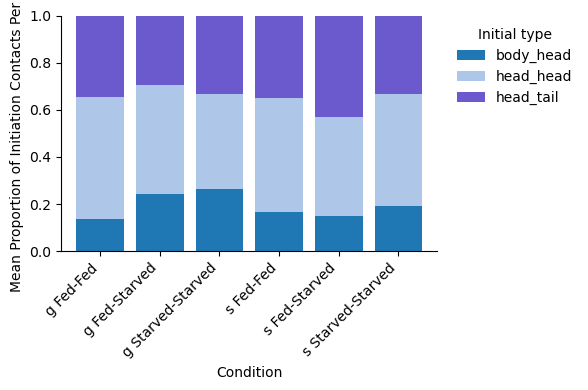

In [91]:
# Proportion of each initiation/contact type per file, averaged within condition.
initial_type_order = sorted(all_bouts['initial_type'].dropna().unique())

initial_type_counts = (
    all_bouts.groupby(['Social experience', 'Food condition', 'Condition', 'file', 'initial_type'], as_index=False)
      .size()
      .rename(columns={'size': 'n_bouts'})
)
initial_type_counts['file_total_bouts'] = initial_type_counts.groupby(
    ['Social experience', 'Food condition', 'Condition', 'file']
)['n_bouts'].transform('sum')
initial_type_counts['proportion'] = initial_type_counts['n_bouts'] / initial_type_counts['file_total_bouts']

initial_type_prop_per_file = (
    initial_type_counts.pivot_table(
        index=['Social experience', 'Food condition', 'Condition', 'file'],
        columns='initial_type',
        values='proportion',
        fill_value=0,
    )
    .reset_index()
)

initial_type_condition_prop = (
    initial_type_prop_per_file.groupby('Condition')[initial_type_order]
      .mean()
      .reindex(order)
)

display(initial_type_condition_prop.reset_index())

initial_type_palette = dict(
    zip(initial_type_order, sns.color_palette('tab20', n_colors=len(initial_type_order)))
)
for head_tail_label in ['head_tail', 'head tail', 'head-tail']:
    if head_tail_label in initial_type_palette:
        initial_type_palette[head_tail_label] = '#6A5ACD'

ax = initial_type_condition_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 4),
    color=[initial_type_palette[initial_type] for initial_type in initial_type_order],
    width=0.8,
)

ax.set_ylim(0, 1)
ax.set_xlabel('Condition')
ax.set_ylabel('Mean Proportion of Initiation Contacts Per File')
ax.set_xticklabels(order, rotation=45, ha='right')
ax.legend(title='Initial type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/GvS_interaction-bouts_initial-type.pdf', format='pdf')
plt.show()


In [92]:
# Helpers for significance labels on the bar plots.
def p_to_star(p_value):
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return ''


def add_star(ax, x1, x2, y, text):
    if text == '':
        return
    step = y * 0.04 if y > 0 else 1
    ax.plot([x1, x1, x2, x2], [y, y + step, y + step, y], color='black', linewidth=1)
    ax.text((x1 + x2) / 2, y + step, text, ha='center', va='bottom')


def add_social_stars(ax, results):
    ymax = max([patch.get_height() for patch in ax.patches] + [1])
    y = ymax * 1.08
    step = ymax * 0.14 if ymax > 0 else 1
    for _, row in results.iterrows():
        comparison = row['Comparison']
        if row['sig'] == '' or 'all food conditions' in comparison:
            continue
        food_condition = comparison.split('(')[1].split(')')[0]
        x1 = order.index('s ' + food_condition)
        x2 = order.index('g ' + food_condition)
        add_star(ax, x1, x2, y, row['sig'])
        y += step
    ax.set_ylim(0, y + step)


def add_condition_stars(ax, results, social_results):
    keep = []
    for social_experience in social_order:
        for food_1, food_2 in combinations(food_order, 2):
            keep.append(f'{social_experience} {food_1} vs {social_experience} {food_2}')
    these_results = results.loc[(results['sig'] != '') & (results['Comparison'].isin(keep))]
    social_results = social_results.loc[(social_results['sig'] != '') & (~social_results['Comparison'].str.contains('all food conditions'))]
    if len(these_results) == 0:
        if len(social_results) == 0:
            return
    ymax = max([patch.get_height() for patch in ax.patches] + [1])
    y = ymax * 1.08
    step = ymax * 0.14 if ymax > 0 else 1
    for _, row in these_results.iterrows():
        group_1, group_2 = row['Comparison'].split(' vs ')
        x1 = order.index(group_1)
        x2 = order.index(group_2)
        add_star(ax, x1, x2, y, row['sig'])
        y += step
    for _, row in social_results.iterrows():
        food_condition = row['Comparison'].split('(')[1].split(')')[0]
        x1 = order.index('s ' + food_condition)
        x2 = order.index('g ' + food_condition)
        add_star(ax, x1, x2, y, row['sig'])
        y += step
    ax.set_ylim(0, y + step)


def add_initial_social_stars(ax, results, initial_type):
    ymax = max([patch.get_height() for patch in ax.patches] + [1])
    y = ymax * 1.08
    step = ymax * 0.14 if ymax > 0 else 1
    these_results = results.loc[results['initial_type'] == initial_type]
    for _, row in these_results.iterrows():
        if row['sig'] == '':
            continue
        x = food_order.index(row['Food condition'])
        add_star(ax, x - 0.2, x + 0.2, y, row['sig'])
        y += step
    ax.set_ylim(0, y + step)


In [93]:
# Keep only the interaction type analysed below.
interaction_type = 'head_head'

available_initial_types = sorted(all_bouts['initial_type'].dropna().unique())
if interaction_type not in available_initial_types:
    raise ValueError(
        f"interaction_type must be one of {available_initial_types}; got {interaction_type!r}"
    )

df = all_bouts.loc[all_bouts['initial_type'] == interaction_type].copy()
df['interaction_number'] = df.groupby(['Condition', 'file']).cumcount() + 1

print(f"Keeping initial_type == {interaction_type!r}")
display(
    all_bouts.groupby(['Social experience', 'Food condition', 'Condition', 'initial_type'])
      .size()
      .rename('n_bouts')
      .reset_index()
)


Keeping initial_type == 'head_head'


,Social experience,Food condition,Condition,initial_type,n_bouts
0,g,Fed-Fed,g Fed-Fed,body_head,13
1,g,Fed-Fed,g Fed-Fed,head_head,38
2,g,Fed-Fed,g Fed-Fed,head_tail,35
3,g,Fed-Starved,g Fed-Starved,body_head,21
4,g,Fed-Starved,g Fed-Starved,head_head,68
5,g,Fed-Starved,g Fed-Starved,head_tail,46
6,g,Starved-Starved,g Starved-Starved,body_head,17
7,g,Starved-Starved,g Starved-Starved,head_head,27
8,g,Starved-Starved,g Starved-Starved,head_tail,19
9,s,Fed-Fed,s Fed-Fed,body_head,15


In [94]:
# Number of selected bouts per file.
file_index = all_bouts[['Social experience', 'Food condition', 'Condition', 'file']].drop_duplicates()

bout_counts = (
    file_index.merge(
        df.groupby(['Social experience', 'Food condition', 'Condition', 'file'], as_index=False)
          .size()
          .rename(columns={'size': 'n_bouts'}),
        on=['Social experience', 'Food condition', 'Condition', 'file'],
        how='left',
    )
    .fillna({'n_bouts': 0})
)
bout_counts['n_bouts'] = bout_counts['n_bouts'].astype(int)

display(
    bout_counts.groupby('Condition')['n_bouts']
      .agg(n_files='count', mean='mean', sd='std')
      .reset_index()
)
display(
    bout_counts.groupby('Social experience')['n_bouts']
      .agg(n_files='count', mean='mean', sd='std')
      .reset_index()
)


,Condition,n_files,mean,sd
0,g Fed-Fed,20,1.900000,1.372665
1,g Fed-Starved,24,2.833333,3.522186
2,g Starved-Starved,15,1.800000,2.210365
3,s Fed-Fed,21,2.095238,1.841325
4,s Fed-Starved,14,1.428571,1.283881
5,s Starved-Starved,16,1.562500,1.412740


,Social experience,n_files,mean,sd
0,g,59,2.254237,2.636568
1,s,51,1.745098,1.572808


In [95]:
# Mann-Whitney tests for bout counts across all condition pairs.
count_results = []
for group_1, group_2 in combinations(order, 2):
    values_1 = bout_counts.loc[bout_counts['Condition'] == group_1, 'n_bouts']
    values_2 = bout_counts.loc[bout_counts['Condition'] == group_2, 'n_bouts']
    stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')
    count_results.append({
        'Comparison': f'{group_1} vs {group_2}',
        'n 1': len(values_1),
        'n 2': len(values_2),
        'Mann-Whitney U': stat,
        'p value': p_value,
        'sig': p_to_star(p_value),
    })

count_mann_whitney_results = pd.DataFrame(count_results)
display(count_mann_whitney_results)


,Comparison,n 1,n 2,Mann-Whitney U,p value,sig
0,g Fed-Fed vs g Fed-Starved,20,24,250.5,0.806993,
1,g Fed-Fed vs g Starved-Starved,20,15,179.0,0.328145,
2,g Fed-Fed vs s Fed-Fed,20,21,200.0,0.799103,
3,g Fed-Fed vs s Fed-Starved,20,14,167.0,0.338718,
4,g Fed-Fed vs s Starved-Starved,20,16,185.5,0.410875,
5,g Fed-Starved vs g Starved-Starved,24,15,209.0,0.395603,
6,g Fed-Starved vs s Fed-Fed,24,21,239.0,0.771046,
7,g Fed-Starved vs s Fed-Starved,24,14,192.0,0.462461,
8,g Fed-Starved vs s Starved-Starved,24,16,217.0,0.482137,
9,g Starved-Starved vs s Fed-Fed,15,21,126.0,0.309117,


In [96]:
# Mann-Whitney tests for group-housed vs socially isolated bout counts.
count_social_results = []
for food_condition in ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']:
    values_g = bout_counts.loc[(bout_counts['Food condition'] == food_condition) & (bout_counts['Social experience'] == 'g'), 'n_bouts']
    values_s = bout_counts.loc[(bout_counts['Food condition'] == food_condition) & (bout_counts['Social experience'] == 's'), 'n_bouts']
    stat, p_value = mannwhitneyu(values_g, values_s, alternative='two-sided')
    count_social_results.append({
        'Comparison': f'g vs s ({food_condition})',
        'n g': len(values_g),
        'n s': len(values_s),
        'Mann-Whitney U': stat,
        'p value': p_value,
        'sig': p_to_star(p_value),
    })

values_g = bout_counts.loc[bout_counts['Social experience'] == 'g', 'n_bouts']
values_s = bout_counts.loc[bout_counts['Social experience'] == 's', 'n_bouts']
stat, p_value = mannwhitneyu(values_g, values_s, alternative='two-sided')
count_social_results.append({
    'Comparison': 'g vs s (all food conditions)',
    'n g': len(values_g),
    'n s': len(values_s),
    'Mann-Whitney U': stat,
    'p value': p_value,
    'sig': p_to_star(p_value),
})

count_social_mann_whitney_results = pd.DataFrame(count_social_results)
display(count_social_mann_whitney_results)


,Comparison,n g,n s,Mann-Whitney U,p value,sig
0,g vs s (Fed-Fed),20,21,200.0,0.799103,
1,g vs s (Fed-Starved),24,14,192.0,0.462461,
2,g vs s (Starved-Starved),15,16,116.5,0.902596,
3,g vs s (all food conditions),59,51,1547.0,0.796058,


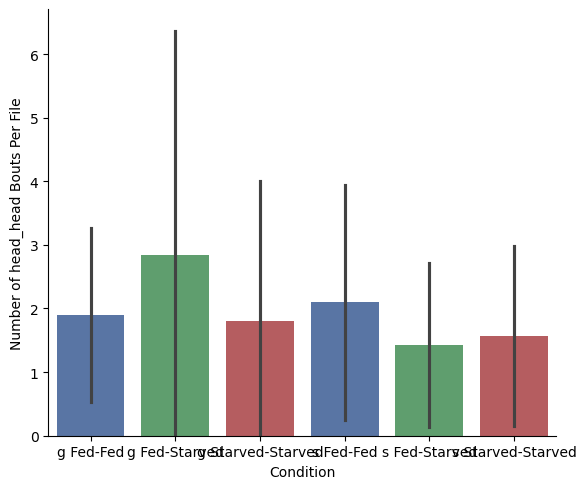

In [97]:
# Plot number of selected bouts per file.
plt.figure(figsize=(6,5))

sns.barplot(
    data=bout_counts,
    x='Condition',
    y='n_bouts',
    hue='Condition',
    order=order,
    hue_order=order,
    palette=palette,
    errorbar='sd',
    legend=False,
)

add_condition_stars(plt.gca(), count_mann_whitney_results, count_social_mann_whitney_results)
plt.ylim(0, plt.gca().get_ylim()[1])
plt.ylabel(f'Number of {interaction_type} Bouts Per File')
plt.xlabel('Condition')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/GvS_interaction-bout-count.pdf', format='pdf')
plt.show()


In [98]:
# Mean duration of selected bouts per file.
duration_per_file = (
    df.groupby(['Social experience', 'Food condition', 'Condition', 'file'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

display(
    duration_per_file.groupby('Condition')['mean_bout_duration']
      .agg(n_files='count', mean='mean', sd='std')
      .reset_index()
)
display(
    duration_per_file.groupby('Social experience')['mean_bout_duration']
      .agg(n_files='count', mean='mean', sd='std')
      .reset_index()
)


,Condition,n_files,mean,sd
0,g Fed-Fed,18,5.566667,3.342673
1,g Fed-Starved,20,11.077525,12.413455
2,g Starved-Starved,10,6.923810,2.826061
3,s Fed-Fed,17,3.884804,2.103936
4,s Fed-Starved,10,2.691667,1.638677
5,s Starved-Starved,12,6.118056,4.507353


,Social experience,n_files,mean,sd
0,g,48,8.145596,8.624778
1,s,39,4.266026,3.190807


In [99]:
# Mann-Whitney tests for mean bout duration across all condition pairs.
duration_results = []
for group_1, group_2 in combinations(order, 2):
    values_1 = duration_per_file.loc[duration_per_file['Condition'] == group_1, 'mean_bout_duration']
    values_2 = duration_per_file.loc[duration_per_file['Condition'] == group_2, 'mean_bout_duration']
    stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')
    duration_results.append({
        'Comparison': f'{group_1} vs {group_2}',
        'n 1': len(values_1),
        'n 2': len(values_2),
        'Mann-Whitney U': stat,
        'p value': p_value,
        'sig': p_to_star(p_value),
    })

duration_mann_whitney_results = pd.DataFrame(duration_results)
display(duration_mann_whitney_results)


,Comparison,n 1,n 2,Mann-Whitney U,p value,sig
0,g Fed-Fed vs g Fed-Starved,18,20,105.5,0.030119,*
1,g Fed-Fed vs g Starved-Starved,18,10,70.0,0.348755,
2,g Fed-Fed vs s Fed-Fed,18,17,196.5,0.155055,
3,g Fed-Fed vs s Fed-Starved,18,10,138.0,0.022370,*
4,g Fed-Fed vs s Starved-Starved,18,12,109.0,0.983060,
5,g Fed-Starved vs g Starved-Starved,20,10,130.0,0.193751,
6,g Fed-Starved vs s Fed-Fed,20,17,278.5,0.000984,***
7,g Fed-Starved vs s Fed-Starved,20,10,174.5,0.001106,**
8,g Fed-Starved vs s Starved-Starved,20,12,168.0,0.064100,
9,g Starved-Starved vs s Fed-Fed,10,17,138.0,0.008074,**


In [100]:
# Mann-Whitney tests for group-housed vs socially isolated mean bout duration.
duration_social_results = []
for food_condition in ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']:
    values_g = duration_per_file.loc[(duration_per_file['Food condition'] == food_condition) & (duration_per_file['Social experience'] == 'g'), 'mean_bout_duration']
    values_s = duration_per_file.loc[(duration_per_file['Food condition'] == food_condition) & (duration_per_file['Social experience'] == 's'), 'mean_bout_duration']
    stat, p_value = mannwhitneyu(values_g, values_s, alternative='two-sided')
    duration_social_results.append({
        'Comparison': f'g vs s ({food_condition})',
        'n g': len(values_g),
        'n s': len(values_s),
        'Mann-Whitney U': stat,
        'p value': p_value,
        'sig': p_to_star(p_value),
    })

values_g = duration_per_file.loc[duration_per_file['Social experience'] == 'g', 'mean_bout_duration']
values_s = duration_per_file.loc[duration_per_file['Social experience'] == 's', 'mean_bout_duration']
stat, p_value = mannwhitneyu(values_g, values_s, alternative='two-sided')
duration_social_results.append({
    'Comparison': 'g vs s (all food conditions)',
    'n g': len(values_g),
    'n s': len(values_s),
    'Mann-Whitney U': stat,
    'p value': p_value,
    'sig': p_to_star(p_value),
})

duration_social_mann_whitney_results = pd.DataFrame(duration_social_results)
display(duration_social_mann_whitney_results)


,Comparison,n g,n s,Mann-Whitney U,p value,sig
0,g vs s (Fed-Fed),18,17,196.5,0.155055,
1,g vs s (Fed-Starved),20,10,174.5,0.001106,**
2,g vs s (Starved-Starved),10,12,73.5,0.390668,
3,g vs s (all food conditions),48,39,1369.0,0.000219,***


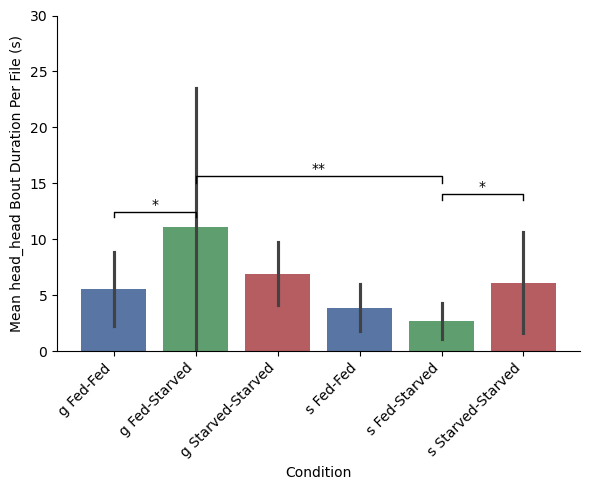

In [101]:
# Plot mean duration of selected bouts per file.
plt.figure(figsize=(6,5))

sns.barplot(
    data=duration_per_file,
    x='Condition',
    y='mean_bout_duration',
    hue='Condition',
    order=order,
    hue_order=order,
    palette=palette,
    errorbar='sd',
    legend=False,
)

add_condition_stars(plt.gca(), duration_mann_whitney_results, duration_social_mann_whitney_results)
plt.ylim(0, 30)
plt.xticks(rotation=45, ha='right')
plt.ylabel(f'Mean {interaction_type} Bout Duration Per File (s)')
plt.xlabel('Condition')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/GvS_interaction-bout-duration.pdf', format='pdf')
plt.show()
